In [1]:
!pip install lightning scanpy

In [2]:
# Clone the Cajal repository to access ddmec subproject files
!git clone https://github.com/giuliofranzese/Cajal.git

fatal: destination path 'Cajal' already exists and is not an empty directory.


In [3]:
import sys
import os
from pathlib import Path

# 1. Define absolute paths based on the directory listing observed
project_root = '/content/Cajal/ddmec'
src_path = os.path.join(project_root, 'src')

# 2. Add paths to sys.path
# We prioritize project_root because pbmc_args.py and data_loader.py are there
for p in [project_root, src_path]:
    if p not in sys.path:
        sys.path.insert(0, p)

# 3. Imports
import numpy as np
import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset

# According to previous output, these are in project_root (/content/Cajal/ddmec)
import args_pbmc
from data_loader import load_pbmc_data

# These are in src (/content/Cajal/ddmec/src)
from continuous.mec_last import MEC
from models.new_mlp import ConditionalDenoiserMLP

def robust_isotropic_standardize(X, clip_threshold=None):
    med = np.median(X, axis=0)
    Xc = X - med[np.newaxis, :]
    mad = np.median(np.abs(Xc))
    robust_std = mad * 1.4826
    Xs = Xc / robust_std
    if clip_threshold is not None:
        Xs = np.clip(Xs, -clip_threshold, clip_threshold)
    return Xs, med, robust_std

class IndependentDataset(Dataset):
    def __init__(self, data):
        self.data = data
        self.indices = torch.randperm(len(self.data))
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[self.indices[idx]]

class MultiModalDataModule(pl.LightningDataModule):
    def __init__(self, x1, x2, batch_size=64, num_workers=4):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.x1_dataset = IndependentDataset(x1)
        self.x2_dataset = IndependentDataset(x2)
    def train_dataloader(self):
        g1 = torch.Generator().manual_seed(torch.initial_seed() % 2**32)
        g2 = torch.Generator().manual_seed((torch.initial_seed() + 1) % 2**32)
        x1_loader = DataLoader(self.x1_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, drop_last=True, generator=g1)
        x2_loader = DataLoader(self.x2_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers, drop_last=True, generator=g2)
        return x1_loader, x2_loader

class mod():
    def __init__(self, name="x", size=17):
        self.name = name
        self.size = size

# Using args_pbmc instead of src.pbmc_args based on file location
parser = args_pbmc.get_namespace()
args = parser.parse_args([])
pl.seed_everything(args.seed)

source_tech, target_tech, meta_source, meta_target = load_pbmc_data()
X = source_tech.to_numpy().astype(float)
y = target_tech.to_numpy().astype(float)

X, med_X, std_X = robust_isotropic_standardize(X, clip_threshold=15)
y, med_y, std_y = robust_isotropic_standardize(y, clip_threshold=25)

intervals = [[np.min(X), np.max(X)], [np.min(y), np.max(y)]]
modalities = [mod("x", X.shape[1]), mod("y", y.shape[1])]
stat = [{"mean": np.mean(X), "std": np.std(X)}, {"mean": np.mean(y), "std": np.std(y)}]

model1 = ConditionalDenoiserMLP(input_dim=X.shape[1], cond_dim=y.shape[1], embedding_dim=128, hidden_dim=128*3, cond_method=args.cond_method)
model2 = ConditionalDenoiserMLP(input_dim=y.shape[1], cond_dim=X.shape[1], embedding_dim=128, hidden_dim=128*3, cond_method=args.cond_method)

model = MEC(modalities, models=[model1, model2], exp="PBMC", intervals=intervals, preporcess=None, args=args, stat=stat,
            test_set={"x1": {"Celltype": meta_target["Celltype"], "Subcelltype": meta_target["Subcelltype"]},
                      "x2": {"Celltype": meta_target["Celltype"], "Subcelltype": meta_target["Subcelltype"]}},
            data=[torch.tensor(X), torch.tensor(y)])

model.set_up__priors_diffusion()
check = torch.hub.load_state_dict_from_url("https://huggingface.co/buckets/mustabou/mybucket/resolve/pbmc.ckpt?download=true", map_location="cpu", check_hash=False)
model.load_state_dict(check["state_dict"])
model = model.to("cuda")
print("Model loaded successfully!")

INFO:lightning_fabric.utilities.seed:Seed set to 88


Downloading: "https://huggingface.co/buckets/mustabou/mybucket/resolve/pbmc.ckpt?download=true" to /root/.cache/torch/hub/checkpoints/pbmc.ckpt


100%|██████████| 30.5M/30.5M [00:00<00:00, 43.7MB/s]


Model loaded successfully!


({'CTM': [np.float64(72.22435651171725), np.float64(71.1102573953131)],
  'SCTM': [np.float64(47.95428351901652), np.float64(49.481367652708414)],
  'CTM_proj': [np.float64(71.3311563580484), np.float64(70.43795620437956)],
  'SCTM_proj': [np.float64(46.53284671532847),
   np.float64(49.058778332693045)]},
 <Figure size 1455.6x480 with 2 Axes>)

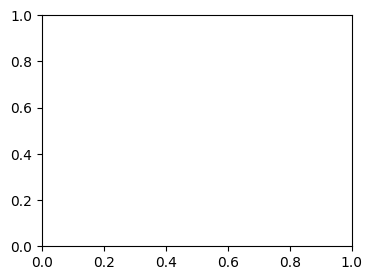

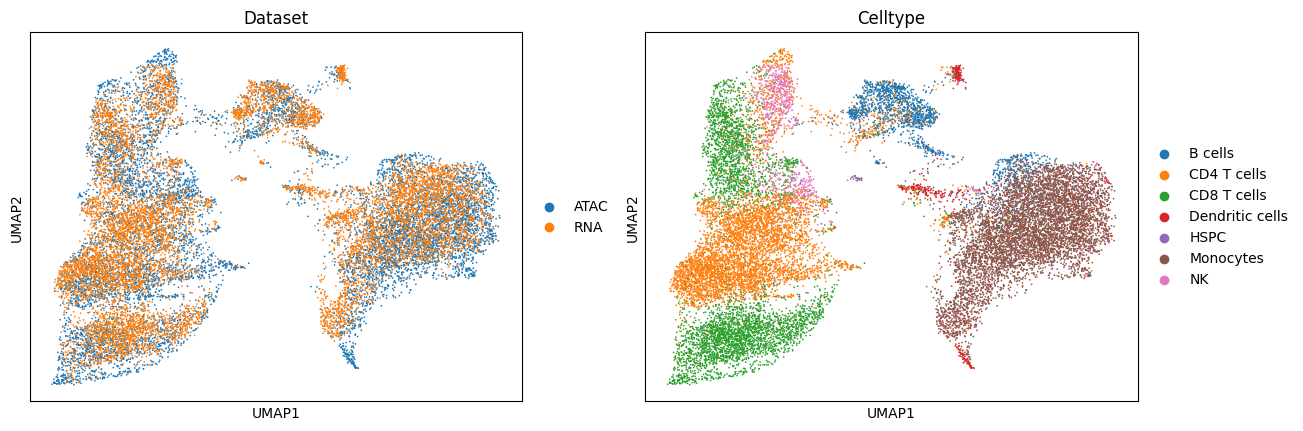

In [4]:

out =model.eval_coupling_2(guidance=3,nb_step=10,clip_gen=False,eta=0.1)
out